<a href="https://colab.research.google.com/github/uprcs-voyager/BERTopic_gojekreview_project/blob/main/BERTopic_gojek_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bertopic sentence-transformers pandas Sastrawi

In [ ]:
import pandas as pd
from google.colab import files
file_path  = '/content/drive/MyDrive/BERTopic_gojek_project/data/raw/gojek.csv'
df = pd.read_csv(file_path)

/tmp/ipykernel_1160/1454087958.py:4: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


#Version Checking

In [ ]:
import pandas
import bertopic
import umap
import hdbscan
import sklearn
import platform
print("Python version:", platform.python_version())
print("pandas version:", pandas.__version__)
print("bertopic version:", bertopic.__version__)
print("umap-learn version:", umap.__version__)
!pip show hdbscan

Python version: 3.12.13
pandas version: 2.2.2
Name: hdbscan
Version: 0.8.44
Summary: Clustering based on density with variable density clusters
Home-page: http://github.com/scikit-learn-contrib/hdbscan
Author: 
Author-email: Leland McInnes <leland.mcinnes@gmail.com>
License: BSD
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, numpy, scikit-learn, scipy
Required-by: bertopic


# Melihat jumlah column dan baris data sebelum di preprcosseing

In [ ]:
print (df.columns)

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')


In [ ]:
df_full  = pd.read_csv(file_path)
print(f"Total data awal adalah: {len(df_full)} baris")

/tmp/ipykernel_1363/260934041.py:1: DtypeWarning:

Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.



Total data awal adalah: 1680532 baris


In [ ]:
print(df_full.isnull().sum())
print()
print(df_full.info())

reviewId                      0
userName                      0
userImage                     0
content                     189
score                         0
thumbsUpCount                 0
reviewCreatedVersion     406660
at                            0
replyContent            1498036
repliedAt               1498036
appVersion               406660
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1680532 entries, 0 to 1680531
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   reviewId              1680532 non-null  object
 1   userName              1680532 non-null  object
 2   userImage             1680532 non-null  object
 3   content               1680343 non-null  object
 4   score                 1680532 non-null  int64 
 5   thumbsUpCount         1680532 non-null  int64 
 6   reviewCreatedVersion  1273872 non-null  object
 7   at                    1680532 non-null  object
 

#cek gpu

In [ ]:
!nvidia-smi

Sat Jun  6 18:27:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Mengambil 20,000 data untuk tiap score rating sekaligus preprocessing

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import umap
import hdbscan
import sklearn
import platform

# Mengambil file raw dan mengambil data dari column content
df_full = pd.read_csv(file_path, low_memory=False).dropna(subset=['content', 'score'])
df_full['date_parsed'] = pd.to_datetime(df_full['at'], errors='coerce')
df_filtered = df_full[(df_full['date_parsed'].dt.year >= 2021) & (df_full['date_parsed'].dt.year <= 2026)].copy()
print(f"sisa data habis kena filter thaun: {len(df_filtered)} baris.")



# membersihjkan text nya <preprocessing>
def clean_text(text):
    text = str(text).lower() #mengubah string menjadi lowercase supaya consisten
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) #membuang URL
    text = re.sub(r'[^a-z0-9\s]', ' ', text) # pengapusan data non alphanumeric/emoji
    text = re.sub(r'\s+', ' ', text).strip() # menormaliassikan spasi
    return text
print("Memberishin text ")
df_filtered['clean_review'] = df_filtered['content'].apply(clean_text)

# ulasan yang panjangnya 3 karakter atau kurang kena buang disini
df_clean = df_filtered[df_filtered['clean_review'].str.len() > 3].copy()
print(f"Sisa data setelah cleaning ada: {len(df_clean)} baris.")





# sisa data yanng bersih tiap rating
print("\ncek sisa  data bersih per skor rating:")
ketersediaan = df_clean['score'].value_counts().sort_index()
print(ketersediaan)



# AMBIL 20,000 reviews darii rating 1 sampai dengan 5 (masing masing 20,000)
target_per_rating = 20000

print(f"\nMengambil data sebanyak {target_per_rating} untuk per skor rating.....tunggu...")

# ekstraksi agar sample nya nanti balanced
df_final = df_clean.groupby('score').sample(n=target_per_rating, random_state=42)

# Verifikasi hasil akhir
print("\nDistribusi Final Dataset:")
print(df_final['score'].value_counts().sort_index())
print(f"Total baris data siap untuk dippake: {len(df_final)}")

# Menyimpan hasil akhir ke file CSV baru (uncomment untuk mengeksekusi)
# save_path = '/content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv'
# df_final[['date_parsed', 'score', 'content', 'clean_review']].to_csv(save_path, index=False)
# print(f"Dataset berhasil disimpan di: {save_path}")





sisa data habis kena filter thaun: 613618 baris.
Memberishin text 
Sisa data setelah cleaning ada: 562847 baris.

cek sisa  data bersih per skor rating:
score
1    129798
2     22317
3     23077
4     33367
5    354288
Name: count, dtype: int64

Mengambil data sebanyak 20000 untuk per skor rating.....tunggu...

Distribusi Final Dataset:
score
1    20000
2    20000
3    20000
4    20000
5    20000
Name: count, dtype: int64
Total baris data siap untuk dippake: 100000
Dataset berhasil disimpan di: /content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv


#Visualisasi data yang sudah siap pakai

Memuat dataset dari: /content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv

Jumlah ulasan per skor rating:
score
1    20000
2    20000
3    20000
4    20000
5    20000
Name: count, dtype: int64


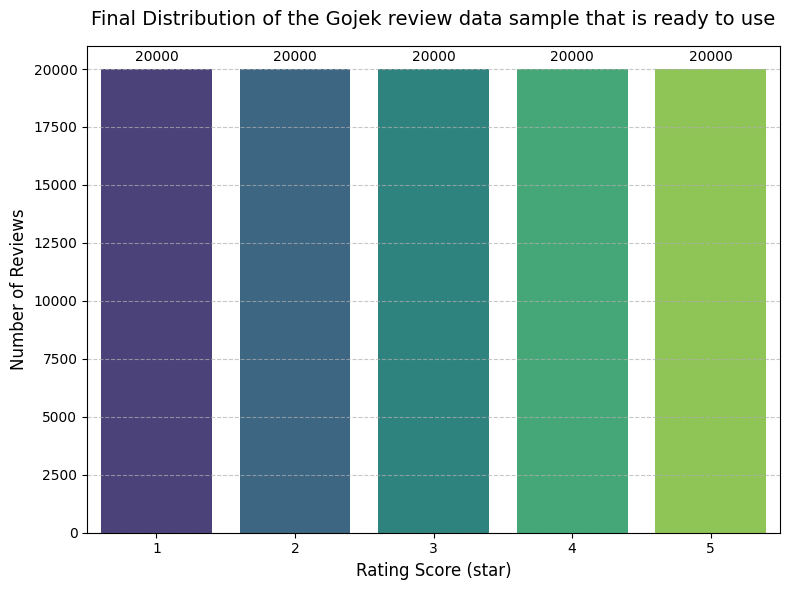

In [ ]:
#MENGAMBIL DATA YANG UDAH SIAP BUAT DIPAKE
file_path_ready = '/content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv'
print(f"Memuat dataset dari: {file_path_ready}")

# Membaca dataset
df_ready = pd.read_csv(file_path_ready)

#Menampilkan perhitungan angka di console
print("\nJumlah ulasan per skor rating:")
print(df_ready['score'].value_counts().sort_index())

#Membuat visualisasi grafik batang
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    x='score',
    data=df_ready,
    palette='viridis',
    order=[1, 2, 3, 4, 5]
)

# Menambahkan label angka eksak di atas setiap batang grafik
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

# Format tampilan grafik
plt.title('Final Distribution of the Gojek review data sample that is ready to use', fontsize=14, pad=15)
plt.xlabel('Rating Score (star)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Eksekusi render grafik
plt.tight_layout()
plt.show()

#Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#INSTALL GENSIM


In [ ]:
!pip install gensim

#===PARAMS TESTING===============

#DISTILUSE PARAMS TESTING

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from cuml.manifold import UMAP
import hdbscan
import sklearn
import platform
import itertools
import time
import gc
import numpy as np
import random

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)


from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel






# EVALUATION METRICS
def hitung_coherence(topic_model, docs):
    """Menghitung rata-rata skor C_v dan C_npmi menggunakan Gensim dengan proteksi Dictionary."""
    topics = topic_model.get_topics()
    topics.pop(-1, None) # Abaikan outlier

    if len(topics) == 0:
        return 0.0, 0.0

    # Tokenisasi dan bentuk kamus (dictionary)
    analyzer = topic_model.vectorizer_model.build_analyzer()
    tokens = [analyzer(doc) for doc in docs]
    dictionary = Dictionary(tokens)

    # Ekstraksi kata topik pake safeguard
    topic_words = []
    for t in topics:
        valid_words = []
        for word, _ in topic_model.get_topic(t):
            # Jika kata valid di kamus Gensim, masukkan
            if word in dictionary.token2id:
                valid_words.append(word)
            else:
                # Jika ditolak (misal sisa bigram/karakter aneh), pecah dan periksa lagi
                for w in word.split():
                    if w in dictionary.token2id and w not in valid_words:
                        valid_words.append(w)

        valid_words = valid_words[:10]
        if len(valid_words) >= 2:
            topic_words.append(valid_words)

    #buang topik jika kosong setelah disaring
    topic_words = [tw for tw in topic_words if len(tw) > 0]

    if len(topic_words) == 0:
        return 0.0, 0.0

    # Komputasi Gensim
    cm_cv = CoherenceModel(topics=topic_words, texts=tokens, dictionary=dictionary, coherence='c_v')
    cm_npmi = CoherenceModel(topics=topic_words, texts=tokens, dictionary=dictionary, coherence='c_npmi')

    return round(cm_cv.get_coherence(), 4), round(cm_npmi.get_coherence(), 4)





def hitung_jaccard_similarity(topic_model):
    "Menghitung Jaccard Similarity"
    "Semakin rendah skornya, semakin bagus artinya "
    topics = topic_model.get_topics()
    topics.pop(-1, None) # Abaikan outlier

    if len(topics) < 2:
        return 1.0 # Jika hanya 1 topik, similarity dianggap absolut

    words_per_topic = []
    for t in topics:
        words = [word for word, _ in topic_model.get_topic(t)[:10]]
        words_per_topic.append(set(words))

    jaccard_sims = []
    for set1, set2 in itertools.combinations(words_per_topic, 2):
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard_sims.append(intersection / union if union > 0 else 0)

    return round(sum(jaccard_sims) / len(jaccard_sims), 4)






# file path buat dapetin csv yang sudah clean
file_path = '/content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv'
df_ready = pd.read_csv(file_path)
docs_ready = df_ready['clean_review'].astype(str).tolist()



# MODE;;L EMBEDDING DAN VECTORIZER

print("menambahkan model embedding dan vectorizerrrzzzz......")
embedding_model = SentenceTransformer("distiluse-base-multilingual-cased-v2")
print("Menggunakan distiluse-base-multilingual-cased-v2..................")

# stop words dan stop words custom
factory = StopWordRemoverFactory()
id_stopwords = factory.get_stop_words() + [
    'gojek', 'aplikasi', 'app', 'apk', 'nya', 'yg', 'di', 'ke', 'dan', 'ini', 'itu',
    'untuk', 'dari', 'ada', 'sudah', 'bisa', 'gak', 'ga', 'enggak', 'tidak', 'aja',
    'saja', 'buat', 'sama', 'kalo', 'kalau', 'saya', 'aku', 'kasih', 'bintang', 'tq', 'be', 'pt', 'lo', 'ni', 'gi'
]
vectorizer_model = CountVectorizer(stop_words=id_stopwords, min_df=10)





# PARAMETERS TO TEST
# n_components_list digunakan di UMAP
#default n_components ini adalah 5 dan disini kami mencoba untuk melakukan eksploraso double dari nilai default nya yaitu 10
n_components_list = [5, 10] #parameter ini mereferensikan dimensionalitas dari embedding setelah direduksi disini kami mencoba 5 atau 10


# min_cluster_sizes digunakan di HDBSCAN
# dokumentasi BERTopic menyarankan untuk meningkatkan minimal cluster size dari nilai default nya yaitu 10
min_cluster_sizes = [50, 100, 150] #secara default ini di set di nilai 10




hasil_evaluasi = []


print("Memulai grid search")

for n_comp, min_c_size in itertools.product(n_components_list, min_cluster_sizes):
    start_time = time.time()
    print(f"Iterasi: n_components={n_comp} | minimal_cluster_size={min_c_size}")

    # cuML-UMAP PARAMTERS
    print("Menyiapkan UMAP nya.....")
    umap_model = UMAP(
        n_neighbors=15, #default
        n_components=n_comp,
        min_dist=0.0,
        metric='cosine',
        random_state =42,
    )
    # HDBSCAN THIS
    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size=min_c_size,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )


    #THE BERTopic
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        top_n_words = 10, #default
        min_topic_size=min_c_size,
        language="multilingual",
        calculate_probabilities=False,
        verbose=True
    )

    print("Memulai proses topic modeling....")
    hasil = topic_model.fit_transform(docs_ready)

    daftar_topik = hasil[0]
    tingkat_kepercayaan_model = hasil[1]

    # METRICS EVALUTION
    print("\nSKOR SEDANG DIPERIKSA......")
    cv_score, npmi_score = hitung_coherence(topic_model, docs_ready)
    jaccard_score = hitung_jaccard_similarity(topic_model)

    # INFO tentang topik yanf dihasilkan
    info_topik = topic_model.get_topic_info()
    total_topik_tanpa_outlier = len(info_topik[info_topik['Topic'] != -1])
    waktu_eksekusi = round(time.time() - start_time, 2)

    # Pencatatan
    hasil_evaluasi.append({
        'n_components': n_comp,
        'minimal_cluster_size': min_c_size,
        'total_topik': total_topik_tanpa_outlier,
        'C_v': cv_score,
        'C_npmi': npmi_score,
        'Jaccard_Sim': jaccard_score,
        'Waktu_(s)': waktu_eksekusi
    })

    print(f"Topik terbentuk: {total_topik_tanpa_outlier} | C_v: {cv_score} | C_npmi: {npmi_score} | Jaccard: {jaccard_score} | Waktu: {waktu_eksekusi}s")
    # Pembersihan VRAM dan RAM supaya nggak crach
    del umap_model, hdbscan_model, topic_model, hasil, daftar_topik, tingkat_kepercayaan_model
    gc.collect()


print("===HASIL AKHIR PARAMETERS TESTING DISTILUSE===")
df_hasil = pd.DataFrame(hasil_evaluasi)
print(df_hasil.to_string(index=False))
print("\n")

menambahkan model embedding dan vectorizerrrzzzz......


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.46k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-06-14 15:39:13,804 - BERTopic - Embedding - Transforming documents to embeddings.


Iterasi: n_components=10 | minimal_cluster_size=150
Menyiapkan UMAP nya.....
Memulai proses topic modeling....


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

2026-06-14 15:40:46,126 - BERTopic - Embedding - Completed ✓
2026-06-14 15:40:46,129 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-14 15:40:55,345 - BERTopic - Dimensionality - Completed ✓
2026-06-14 15:40:55,351 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-14 15:41:25,537 - BERTopic - Cluster - Completed ✓
2026-06-14 15:41:25,559 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-14 15:41:26,447 - BERTopic - Representation - Completed ✓



SKOR SEDANG DIPERIKSA......
Topik terbentuk: 67 | C_v: 0.5799 | C_npmi: 0.0178 | Jaccard: 0.0208 | Waktu: 151.24s
===HASIL AKHIR PARAMETERS TESTING DISTILUSE===
 n_components  minimal_cluster_size  total_topik    C_v  C_npmi  Jaccard_Sim  Waktu_(s)
            5                    50          220 0.5103 -0.0167       0.0163     142.40
            5                   100          116 0.5610  0.0304       0.0202     139.62
            5                   150           62 0.5916  0.0559       0.0217     140.20
           10                    50          211 0.5113 -0.0175       0.0180     150.90
           10                   100          113 0.5597  0.0189       0.0185     152.56
           10                   150           67 0.5799  0.0178       0.0208     151.24




#MINILM PARAMS TESTING

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from cuml.manifold import UMAP
import hdbscan
import sklearn
import platform
import itertools
import time
import gc
import numpy as np
import random

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)


from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel







# EVALUATIONN METRICS
def hitung_coherence(topic_model, docs):
    """Menghitung rata-rata skor C_v dan C_npmi menggunakan Gensim dengan proteksi Dictionary."""
    topics = topic_model.get_topics()
    topics.pop(-1, None) # Abaikan outlier

    if len(topics) == 0:
        return 0.0, 0.0

    # Tokenisasi dan bentuk kamus (dictionary)
    analyzer = topic_model.vectorizer_model.build_analyzer() #mengambil aturan pemotongan kata yang sama dengan yang digunakan BERTopic
    tokens = [analyzer(doc) for doc in docs] #memecah 100,000 ulasan menjadi sekumpulan array tunggal seperti [['aplikasi, driver, ....]]
    dictionary = Dictionary(tokens) #gensim mendaftarkan semua kata unik dan memberi mereka ID angka

    # Ekstraksi kata topik pake safeguard
    """ ini digunakan karena BERTopic meng ekstrak kata kunci menggunakan vektor (c-tf-idf) jadi kadang menghasilkan kata seperti
     driver cancel, yang merupakan frasa gabungan dan masalahnya adalah di dictionary gensim yang sudah dibuat tadi
     dua kata tersebut terpisah dan memiliki id yang berbeda
    """
    topic_words = []
    for t in topics:
        valid_words = []
        for word, _ in topic_model.get_topic(t):
            # mengecek apakah kata ada di kamus yang sudah dibuat tadi (dictionary = Dictionary(tokens))
            if word in dictionary.token2id:
                valid_words.append(word)
            else:
                # proses pemecahan kata driver cancel
                for w in word.split():
                    if w in dictionary.token2id and w not in valid_words: # masukan kata 'driver, cancel' ke valid_words jika kata-kata yang sudah dipecah tersebut ada di kamus
                        valid_words.append(w)

        valid_words = valid_words[:10] #
        if len(valid_words) >= 2:
            topic_words.append(valid_words)

    #buang topik jika kebetulan kosong setelah disaring
    topic_words = [tw for tw in topic_words if len(tw) > 0]

    if len(topic_words) == 0:
        return 0.0, 0.0

    # Komputasi Gensim
    cm_cv = CoherenceModel(topics=topic_words, texts=tokens, dictionary=dictionary, coherence='c_v')
    cm_npmi = CoherenceModel(topics=topic_words, texts=tokens, dictionary=dictionary, coherence='c_npmi')

    return round(cm_cv.get_coherence(), 4), round(cm_npmi.get_coherence(), 4)





def hitung_jaccard_similarity(topic_model):
    "Menghitung Jaccard Similarity"
    "Semakin rendah skornya, semakin bagus artinya "
    topics = topic_model.get_topics()
    topics.pop(-1, None) # Abaikan outlier

    if len(topics) < 2:
        return 1.0 # Jika hanya 1 topik, similarity dianggap absolut

    words_per_topic = []
    for t in topics:
        words = [word for word, _ in topic_model.get_topic(t)[:10]]
        words_per_topic.append(set(words))

    jaccard_sims = []
    for set1, set2 in itertools.combinations(words_per_topic, 2):
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard_sims.append(intersection / union if union > 0 else 0)

    return round(sum(jaccard_sims) / len(jaccard_sims), 4)






# file path buat dapetin csv yang sudah clean
file_path = '/content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv'
df_ready = pd.read_csv(file_path)
docs_ready = df_ready['clean_review'].astype(str).tolist()



# MODEL EMBEDING DAN VECTORIZER
print("menambahkan model embedding dan vectorizer")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# stop words dan stop words custom
factory = StopWordRemoverFactory()
id_stopwords = factory.get_stop_words() + [
    'gojek', 'aplikasi', 'app', 'apk', 'nya', 'yg', 'di', 'ke', 'dan', 'ini', 'itu',
    'untuk', 'dari', 'ada', 'sudah', 'bisa', 'gak', 'ga', 'enggak', 'tidak', 'aja',
    'saja', 'buat', 'sama', 'kalo', 'kalau', 'saya', 'aku', 'kasih', 'bintang', 'tq', 'be', 'pt', 'lo', 'ni', 'gi'
]
vectorizer_model = CountVectorizer(stop_words=id_stopwords, min_df=10)





# PAREMETERS TO TEST
n_components_list = [5, 10]
min_cluster_sizes = [50, 100, 150]
hasil_evaluasi = []



print("Memulai grid search")

for n_comp, min_c_size in itertools.product(n_components_list, min_cluster_sizes):
    start_time = time.time()
    print(f"Iterasi: n_components={n_comp} | minimal_cluster_size={min_c_size}")

    # cuML-UMAP PARAMTERS
    print("Menyiapkan UMAP nya....")
    umap_model = UMAP(
        n_neighbors=15, #default
        n_components=n_comp,
        min_dist=0.0,
        metric='cosine',
        random_state =42,
    )
    # HDBSCAN THIS
    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size=min_c_size,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )


    #THE BERTopic
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        top_n_words = 10,
        min_topic_size=min_c_size,
        language="multilingual",
        calculate_probabilities=False,
        verbose=True
    )

    print("Memulai proses topic modeling")
    hasil = topic_model.fit_transform(docs_ready)

    daftar_topik = hasil[0]
    tingkat_kepercayaan_model = hasil[1]

    # METRICS EVALUTION
    print("\nSKOR SEDANG DIPERIKSA......")
    cv_score, npmi_score = hitung_coherence(topic_model, docs_ready)
    jaccard_score = hitung_jaccard_similarity(topic_model)

    # INFO tentang topik yanf dihasilkan
    info_topik = topic_model.get_topic_info()
    total_topik_tanpa_outlier = len(info_topik[info_topik['Topic'] != -1])
    waktu_eksekusi = round(time.time() - start_time, 2)

    # Pencatatan
    hasil_evaluasi.append({
        'n_components': n_comp,
        'minimal_cluster_size': min_c_size,
        'total_topik': total_topik_tanpa_outlier,
        'C_v': cv_score,
        'C_npmi': npmi_score,
        'Jaccard_Sim': jaccard_score,
        'Waktu_(s)': waktu_eksekusi
    })

    print(f"Topik terbentuk: {total_topik_tanpa_outlier} | C_v: {cv_score} | C_npmi: {npmi_score} | Jaccard: {jaccard_score} | Waktu: {waktu_eksekusi}s")
    # Pembersihan VRAM dan RAM supaya nggak crach
    del umap_model, hdbscan_model, topic_model, hasil, daftar_topik, tingkat_kepercayaan_model
    gc.collect()


print("===HASIL AKHIR PARAMETERS TESTING MINILM===")
df_hasil = pd.DataFrame(hasil_evaluasi)
print(df_hasil.to_string(index=False))
print("\n")




menambahkan model embedding dan vectorizerrrzzzz......


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-06-14 15:12:57,350 - BERTopic - Embedding - Transforming documents to embeddings.


Iterasi: n_components=10 | minimal_cluster_size=150
Menyiapkan UMAP nya....
Memulai proses topic modeling aaaaa...


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

2026-06-14 15:13:56,514 - BERTopic - Embedding - Completed ✓
2026-06-14 15:13:56,516 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-14 15:14:12,587 - BERTopic - Dimensionality - Completed ✓
2026-06-14 15:14:12,593 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-14 15:14:40,987 - BERTopic - Cluster - Completed ✓
2026-06-14 15:14:41,021 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-14 15:14:42,557 - BERTopic - Representation - Completed ✓



SKOR SEDANG DIPERIKSA......
Topik terbentuk: 75 | C_v: 0.6253 | C_npmi: 0.0794 | Jaccard: 0.0177 | Waktu: 123.33s
===HASIL AKHIR PARAMETERS TESTING MINILM===
 n_components  minimal_cluster_size  total_topik    C_v  C_npmi  Jaccard_Sim  Waktu_(s)
            5                    50          212 0.5155 -0.0144       0.0152     116.62
            5                   100           99 0.5695  0.0286       0.0170     108.62
            5                   150           79 0.5973  0.0476       0.0160     112.03
           10                    50          194 0.5231 -0.0083       0.0176     120.85
           10                   100          101 0.5853  0.0500       0.0187     119.54
           10                   150           75 0.6253  0.0794       0.0177     123.33




#LDA PARAMS TESTING

In [ ]:
import pandas as pd
import numpy as np
import time
import gc
import itertools
import random
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from gensim.corpora.dictionary import Dictionary
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel


# for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)




file_path = '/content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv'
df_ready = pd.read_csv(file_path)


docs_ready = df_ready['clean_review'].astype(str).tolist()

#Memproses tokeninasi dan stopwords
print("Memproses tokenisasi dan Stopwords")
factory = StopWordRemoverFactory()
id_stopwords = set(factory.get_stop_words() + [
    'gojek', 'aplikasi', 'app', 'apk', 'nya', 'yg', 'di', 'ke', 'dan', 'ini', 'itu',
    'untuk', 'dari', 'ada', 'sudah', 'bisa', 'gak', 'ga', 'enggak', 'tidak', 'aja',
    'saja', 'buat', 'sama', 'kalo', 'kalau', 'saya', 'aku', 'kasih', 'bintang', 'tq', 'be', 'pt', 'lo', 'ni', 'gi'
])

tokenized_docs = []
for doc in docs_ready:
    tokens = [word for word in doc.split() if word not in id_stopwords and len(word) > 1]
    tokenized_docs.append(tokens)

#membangun kamus dan korpus
print("Membangun kamus (Dictionary) dan Korpus")
dictionary = Dictionary(tokenized_docs)
# Ekuivalen dengan min_df=10 pada CountVectorizer
dictionary.filter_extremes(no_below=10)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

#LDA EVALUATION METRICSSS
def hitung_evaluasi_lda(lda_model, dictionary, tokenized_docs):
    """
    Evaluasi native untuk model LDA Gensim.
    Parameter topn=10.
    """
    # Hitung C_v
    cv_model = CoherenceModel(model=lda_model,
                              texts=tokenized_docs,
                              dictionary=dictionary,
                              coherence='c_v',
                              topn=10)

    # Hitung C_npmi
    npmi_model = CoherenceModel(model=lda_model,
                                texts=tokenized_docs,
                                dictionary=dictionary,
                                coherence='c_npmi',
                                topn=10)

    cv_score = cv_model.get_coherence()
    npmi_score = npmi_model.get_coherence()
    cv_score = 0.0 if np.isnan(cv_score) else cv_score
    npmi_score = 0.0 if np.isnan(npmi_score) else npmi_score

    # Hitung Jaccard Similarity antar Topik
    topics = lda_model.show_topics(num_topics=-1, num_words=10, formatted=False)
    words_per_topic = [set([word for word, prob in topic[1]]) for topic in topics]

    jaccard_sims = []
    for set1, set2 in itertools.combinations(words_per_topic, 2):
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard_sims.append(intersection / union if union > 0 else 0)

    jaccard_score = sum(jaccard_sims) / len(jaccard_sims) if jaccard_sims else 0.0

    return round(cv_score, 4), round(npmi_score, 4), round(jaccard_score, 4)


#testing parameters
num_topics_list = [50, 70, 90]
alpha_list = [0.01, 0.1]

hasil_evaluasi_lda = []
total_iterasi = len(num_topics_list) * len(alpha_list)
iterasi_ke = 1

print(f"\nMemulai Grid Search LDA ({total_iterasi} kombinasi parameter)...")


for k, a in itertools.product(num_topics_list, alpha_list):
    start_time = time.time()
    print(f"\n[{iterasi_ke}/{total_iterasi}] Melatih LDA: K (Topik)={k} | Alpha={a}")

    # menggunakan 4 pekerja inti CPU
    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=seed_value,
        passes=10,
        alpha=a,
        workers=4
    )

    print("SKOR SEDANG DIHITUNG...")
    cv, npmi, jaccard = hitung_evaluasi_lda(lda_model, dictionary, tokenized_docs)
    waktu_eksekusi = round(time.time() - start_time, 2)

    hasil_evaluasi_lda.append({
        'Model': 'LDA Gensim',
        'K (Topik)': k,
        'Alpha': a,
        'C_v': cv,
        'C_npmi': npmi,
        'Jaccard_Sim': jaccard,
        'Waktu_(s)': waktu_eksekusi
    })

    print(f"--> Hasil: C_v: {cv} | C_npmi: {npmi} | Jaccard: {jaccard} | Waktu: {waktu_eksekusi}s")

    # Pembersihan RAM di setiap akhir iterasi
    del lda_model
    gc.collect()
    iterasi_ke += 1


print("\n=== HASIL AKHIR PARAMS TESTING LDA ===")
print("\n")
df_hasil_lda = pd.DataFrame(hasil_evaluasi_lda)
df_hasil_lda = df_hasil_lda.sort_values(by='C_v', ascending=False)

# Menampilkan tabel di layar Colab
display(df_hasil_lda)

Memproses tokenisasi dan Stopwords tunggu ya.....
Membangun kamus (Dictionary) dan Korpus...

Memulai Grid Search LDA (6 kombinasi parameter)...

[1/6] Melatih LDA: K (Topik)=50 | Alpha=0.01
SKOR SEDANG DIHITUNG...
--> Hasil: C_v: 0.5728 | C_npmi: 0.0069 | Jaccard: 0.0065 | Waktu: 281.72s

[2/6] Melatih LDA: K (Topik)=50 | Alpha=0.1
SKOR SEDANG DIHITUNG...
--> Hasil: C_v: 0.5815 | C_npmi: 0.0123 | Jaccard: 0.0063 | Waktu: 254.81s

[3/6] Melatih LDA: K (Topik)=70 | Alpha=0.01
SKOR SEDANG DIHITUNG...
--> Hasil: C_v: 0.5394 | C_npmi: -0.026 | Jaccard: 0.0058 | Waktu: 309.05s

[4/6] Melatih LDA: K (Topik)=70 | Alpha=0.1
SKOR SEDANG DIHITUNG...
--> Hasil: C_v: 0.5182 | C_npmi: -0.0351 | Jaccard: 0.0045 | Waktu: 289.88s

[5/6] Melatih LDA: K (Topik)=90 | Alpha=0.01
SKOR SEDANG DIHITUNG...
--> Hasil: C_v: 0.5098 | C_npmi: -0.0578 | Jaccard: 0.0066 | Waktu: 333.68s

[6/6] Melatih LDA: K (Topik)=90 | Alpha=0.1
SKOR SEDANG DIHITUNG...
--> Hasil: C_v: 0.4795 | C_npmi: -0.0709 | Jaccard: 0.0041 | 

,Model,K (Topik),Alpha,C_v,C_npmi,Jaccard_Sim,Waktu_(s)
1,LDA Gensim,50,0.10,0.5815,0.0123,0.0063,254.81
0,LDA Gensim,50,0.01,0.5728,0.0069,0.0065,281.72
2,LDA Gensim,70,0.01,0.5394,-0.0260,0.0058,309.05
3,LDA Gensim,70,0.10,0.5182,-0.0351,0.0045,289.88
4,LDA Gensim,90,0.01,0.5098,-0.0578,0.0066,333.68
5,LDA Gensim,90,0.10,0.4795,-0.0709,0.0041,324.79


#===PARAMS TESTING=================

#MINILM MAIN MODEL

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from cuml.manifold import UMAP
import hdbscan
import sklearn
import platform
import itertools
import time
import gc
import numpy as np
import random

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)


from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel






# EVALUATION METRICS
def hitung_coherence(topic_model, docs):
    """Menghitung rata-rata skor C_v dan C_npmi menggunakan Gensim dengan proteksi Dictionary."""
    topics = topic_model.get_topics()
    topics.pop(-1, None) # Abaikan outlier

    if len(topics) == 0:
        return 0.0, 0.0

    # Tokenisasi dan bentuk kamus (dictionary)
    analyzer = topic_model.vectorizer_model.build_analyzer() #mengambil aturan pemotongan kata yang sama dengan yang digunakan BERTopic
    tokens = [analyzer(doc) for doc in docs] #memecah 100,000 ulasan menjadi sekumpulan array tunggal seperti [['aplikasi, driver, ....]]
    dictionary = Dictionary(tokens) #gensim mendaftarkan semua kata unik dan memberi mereka ID angka

    # Ekstraksi kata topik pake safeguard
    """ ini digunakan karena BERTopic meng ekstrak kata kunci menggunakan vektor (c-tf-idf) jadi kadang menghasilkan kata seperti
     driver cancel, yang merupakan frasa gabungan dan masalahnya adalah di dictionary gensim yang sudah dibuat tadi
     dua kata tersebut terpisah dan memiliki id yang berbeda
    """
    topic_words = []
    for t in topics:
        valid_words = []
        for word, _ in topic_model.get_topic(t):
           # mengecek apakah kata ada di kamus yang sudah dibuat tadi (dictionary = Dictionary(tokens))
            if word in dictionary.token2id:
                valid_words.append(word)
            else:
               # proses pemecahan kata driver cancel
                for w in word.split():
                    if w in dictionary.token2id and w not in valid_words: # masukan kata 'driver, cancel' ke valid_words jika kata-kata yang sudah dipecah tersebut ada di kamus
                        valid_words.append(w)

        valid_words = valid_words[:10]
        if len(valid_words) >= 2:
            topic_words.append(valid_words)

    #buang topik jika kebetulan kosong setelah disaring
    topic_words = [tw for tw in topic_words if len(tw) > 0]

    if len(topic_words) == 0:
        return 0.0, 0.0

    # Komputasi Gensim
    cm_cv = CoherenceModel(topics=topic_words, texts=tokens, dictionary=dictionary, coherence='c_v')
    cm_npmi = CoherenceModel(topics=topic_words, texts=tokens, dictionary=dictionary, coherence='c_npmi')

    return round(cm_cv.get_coherence(), 4), round(cm_npmi.get_coherence(), 4)



def hitung_jaccard_similarity(topic_model):
    "Menghitung Jaccard Similarity"
    "Semakin rendah skornya, semakin bagus artinya "
    topics = topic_model.get_topics()
    topics.pop(-1, None) # Abaikan outlier

    if len(topics) < 2:
        return 1.0 # Jika hanya 1 topik, similarity dianggap absolut

    words_per_topic = []
    for t in topics:
        words = [word for word, _ in topic_model.get_topic(t)[:10]]
        words_per_topic.append(set(words))

    jaccard_sims = []
    for set1, set2 in itertools.combinations(words_per_topic, 2):
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard_sims.append(intersection / union if union > 0 else 0)

    return round(sum(jaccard_sims) / len(jaccard_sims), 4)




# file path buat dapetin csv yang sudah clean
file_path = '/content/drive/MyDrive/BERTopic_gojek_project/data/processed/gojek_ready_100k.csv'
df_ready = pd.read_csv(file_path)
docs_ready = df_ready['clean_review'].astype(str).tolist()





# MODEL EMBEDDING DAN VECTORIZER

print("menambahkan model embedding dan vectorizer")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# stop words dan stop words custom
factory = StopWordRemoverFactory()
id_stopwords = factory.get_stop_words() + [
    'gojek', 'aplikasi', 'app', 'apk', 'nya', 'yg', 'di', 'ke', 'dan', 'ini', 'itu',
    'untuk', 'dari', 'ada', 'sudah', 'bisa', 'gak', 'ga', 'enggak', 'tidak', 'aja',
    'saja', 'buat', 'sama', 'kalo', 'kalau', 'saya', 'aku', 'kasih', 'bintang', 'tq', 'be', 'pt', 'lo', 'ni', 'gi'
]
vectorizer_model = CountVectorizer(stop_words=id_stopwords, min_df=10)





# PAREMETERS
n_component = 10;
min_cluster_size = 150;



# cuML-UMAP PARAMTERS
print("Menyiapkan UMAP nya")
umap_model = UMAP(
    n_neighbors=15, #default
    n_components=n_component,
    min_dist=0.0,
    metric='cosine',
    random_state =42,
 )
# HDBSCAN THIS
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
 )
#THE BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    top_n_words = 10, #preferebly between 10 and 20, kami memilih 10
    min_topic_size=min_cluster_size,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
 )

start_time = time.time()
print("Memulai proses topic modeling ")
hasil, probs_final = topic_model.fit_transform(docs_ready)

print("\nINFORMASI YANG DIDAPATKAN")
info_final = topic_model.get_topic_info()
print(info_final.head(21))

# # 5. nyimpen model final
# path_simpan = '/content/drive/MyDrive/BERTopic_gojek_project/models/THE_minilm'
# print(f"\nMenyimpan model ke: {path_simpan}")
# topic_model.save(path_simpan, serialization="safetensors", save_ctfidf=True)
# print("Model disimpan!")



# METRICS EVALUTION
print("\nSKOR SEDANG DIPERIKSA......")
cv_score, npmi_score = hitung_coherence(topic_model, docs_ready)
jaccard_score = hitung_jaccard_similarity(topic_model)

# INFO tentang topik yanf dihasilkan
info_topik = topic_model.get_topic_info()
total_topik_tanpa_outlier = len(info_topik[info_topik['Topic'] != -1])
waktu_eksekusi = round(time.time() - start_time, 2)

# Pencatatan
hasil_evaluasi= {
    'Model': 'MiniLM Final',
    'n_components': n_component,
    'min_cluster_size': min_cluster_size,
    'total_topik': total_topik_tanpa_outlier,
    'C_v': cv_score,
    'C_npmi': npmi_score,
    'Jaccard_Sim': jaccard_score,
    'Waktu_(s)': waktu_eksekusi
}


print("\n===DATA TAMBAHAN===")
df_hasil = pd.DataFrame([hasil_evaluasi])
print(df_hasil.to_string(index=False))



# UNCOMMENT AJA KALO MAU LIAT HASILNYA

print("Mengekstrak informasi topik secara utuh...")
# Ambil dataframe informasi topik bawaan BERTopic
info_lengkap = topic_model.get_topic_info()

# # Rapikan format array/list menjadi string dengan proteksi tipe data (isinstance)
# info_lengkap['Representation'] = info_lengkap['Representation'].apply(
#     lambda words: ', '.join([w for w in words if w.strip() != '']) if isinstance(words, list) else str(words)
# )

# # Menambahkan proteksi tipe data yang sama pada dokumen representatif
# info_lengkap['Representative_Docs'] = info_lengkap['Representative_Docs'].apply(
#     lambda docs: ' || '.join(docs) if isinstance(docs, list) else str(docs)
# )

# # Penyimpanan di Google Drive
# path_excel = '/content/drive/MyDrive/BERTopic_gojek_project/articletopicdata/THE_Topik_Lengkap_MiniLM.xlsx'

# # Ekspor ke Excel
# info_lengkap.to_excel(path_excel, index=False)
# print(f"Proses Selesai. File berhasil diekspor dan siap dibuka di: {path_excel}")


menambahkan model embedding dan vectorizerrrzzzz......


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-06-15 17:25:37,563 - BERTopic - Embedding - Transforming documents to embeddings.


Menyiapkan UMAP nya..... tunggu ya.....
Memulai proses topic modeling aaaaa...


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

2026-06-15 17:26:44,597 - BERTopic - Embedding - Completed ✓
2026-06-15 17:26:44,599 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-15 17:27:01,886 - BERTopic - Dimensionality - Completed ✓
2026-06-15 17:27:01,892 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-15 17:28:19,291 - BERTopic - Cluster - Completed ✓
2026-06-15 17:28:19,331 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-15 17:28:20,579 - BERTopic - Representation - Completed ✓



INFORMASI YANG DIDAPATKAN
    Topic  Count                                    Name  \
0      -1  36054              -1_gopay_mau_saldo_padahal   
1       0  11733          0_driver_drivernya_cancel_jauh   
2       1   9464                  1_susah_gopay_lama_mau   
3       2   2747           2_makanan_gofood_pesanan_food   
4       3   2223                             3_mantap___   
5       4   2132                              4_bagus___   
6       5   1779     5_sangat_membantu_aplikasinya_bagus   
7       6   1769                            6_good_one__   
8       7   1341          7_ongkir_mahal_ongkirnya_harga   
9       8   1284          8_voucher_diskon_gofood_hilang   
10      9   1217       9_membantu_sangat_terbantu_sehari   
11     10   1175         10_dulu_bintangnya_soalnya_baru   
12     11   1041  11_pelayanan_pelayanannya_baik_layanan   
13     12   1011          12_update_minta_diupdate_terus   
14     13    911         13_bank_saldo_transfer_rekening   
15     14    

#Visualisasi

In [ ]:
# barchart
topic_model.visualize_barchart(top_n_topics=16)

In [ ]:
#Intertopic Distance Map
topic_model.visualize_topics()